In [16]:
import os
import cv2
import tensorflow as tf  
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils import show_img

In [17]:
train_dir = "chars_train_data/"

In [49]:
# Load training data
def load_dir_pngs_and_preprocess(directory, preprocess):
    labelled_pngs = []
    for (root,dirs,files) in os.walk(directory, topdown=True):
        for file in tqdm(files, desc=f"Loading pngs from '{directory}'"):
            if not file.endswith('.png'):
                continue
            label = file.split("_")[0]
            img_path = os.path.join(root, file)
            labelled_pngs.append((label, preprocess(cv2.imread(img_path))))
    return labelled_pngs


In [52]:
def crop_img(img):
    grey = np.mean(img, axis=2)
    coords = np.argwhere(grey < 255)
    if coords.size == 0:
        return grey 

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped = grey[y_min-1:y_max+2, x_min-1:x_max+2]
    
    # convert to blck n white
    return np.where(cropped == 255, 0, 255)

In [51]:
imgs = load_dir_pngs_and_preprocess(train_dir, crop_img)

Loading pngs from 'chars_train_data/': 100%|██| 44206/44206 [00:46<00:00, 958.57it/s]


y


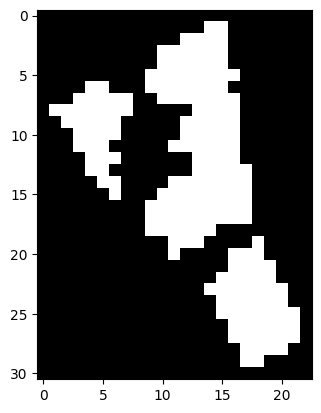

In [54]:
label, img = imgs[44205]
print(label)
show_img(img)